# LKIPA Time Series Data Collection

In this notebook we analyse the noise power of the LKIPA from its power spectrum density. 

----

In [2]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample
import importlib
import LKIPA_PSD as psd
importlib.reload(psd)

<module 'LKIPA_PSD' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/LKIPA_PSD.py'>

# 1. Get PSD from time series pixels

In [4]:
# DATA ACQUISITION
data_all, dt, fs, n_samples, myrun = psd.data_acquisition(
            address=psd.ADDRESS,
            port=psd.PORT,
            converter_configuration=psd.CONVERTER_CONFIGURATION,
            input_port=psd.INPUT_PORT,
            adc_att=psd.ADC_ATT,
            input_nco=psd.INPUT_NCO,
            output_port=psd.FLUX_PORT,
            dac_curr=psd.DAC_CURR,
            amp=psd.PUMP_AMP,
            freq=psd.PUMP_FREQ,
            phasei=psd.PHASEI,
            phaseq=psd.PHASEQ,
            output_nco=psd.PUMP_NCO,
            df=psd.DF,
            dcb_port=psd.DC_PORT,
            dcb_amp=psd.DC_BIAS,
            n_pix=psd.N_PIX
        )

# REMOVE DC COMPONENT AND UNTWIST I\Q quadratures
I_all = psd.remove_DC(data_all=data_all)

Hardware configuration successful, initiating data acquisition ...


100%|███████████████████████████████████████| 5000/5000 [02:59<00:00, 27.84it/s]


Data Acquisition Complete.

MEASUREMENT PARAMETERS:
Mode: AdcMode.Mixed
Number of pixels: 5000
Pixel time resolution (dt): 1.00 ns
Sampling frequency (fs): 1.00 GHz
Total measurement time: 100.0 µs
Frequency resolution (DF): 10.0 kHz
Data points captured per pixel: 200000
Number of samples per pixel: 100000



FITTING PARAMETERS:
A_background =  1.12
B_background =  -0.33
A_peak =  0.1713
f0 =  4.42936 GHz
gamma =  0.493 MHz


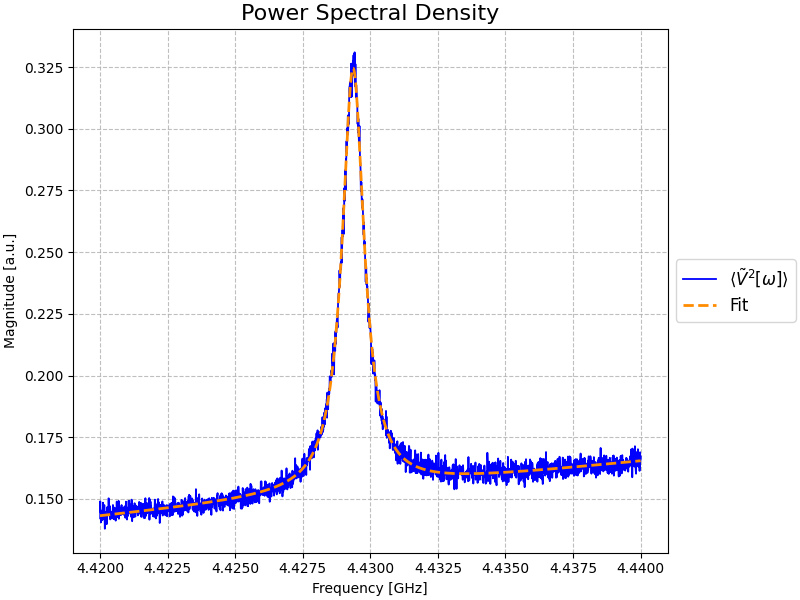

In [5]:
# GET POWER SPECTRAL DENSITY
PSD_avg, f_arr, t_arr = psd.get_PSD_avg(
    I_all=I_all,
    n_samples=n_samples,
    dt=dt
)

# SELECT BANDWIDTH
PSD_bw, f_bw = psd.get_PSD_bw(
    PSD_avg=PSD_avg,
    f_arr=f_arr,
    f_L=0.42,
    f_R=0.44
)

# Fitting parameters
fit_params = psd.lorentz_fit(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw,
    lorentzian_fit_func=psd.lorentzian_fit_func,
    verbose=True
)

# PLOT PSD
psd.plot_PSD_bw(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw,
    fit_params=fit_params,
)

In [22]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Define colors
color_a = '#9d6108'  # Example: Red
color_b = '#12776f'  # Example: Blue
color_c = '#a9ccc7'

# Create custom colormap
cmap_name = 'my_list'
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, [color_a, color_c, color_b])

In [31]:
psd_list = np.loadtxt('/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/Time series data/LKIPA-PSD-df=100khz-pixels=20000.txt')

df = 100e3  # Frequency resolution in Hz
n_samples = len(psd_list)
freq_arr = np.arange(n_samples) * df

# Freq range of interest
f_min = 0.42e9  # 0.42 GHz
f_max = 0.44e9  # 0.44 GHz
indices = np.where((freq_arr >= f_min) & (freq_arr <= f_max))

freq_band =  4 + freq_arr[indices]/1e9
psd_band = psd_list[indices]

Text(0.5, 0, 'Frequency (GHz)')

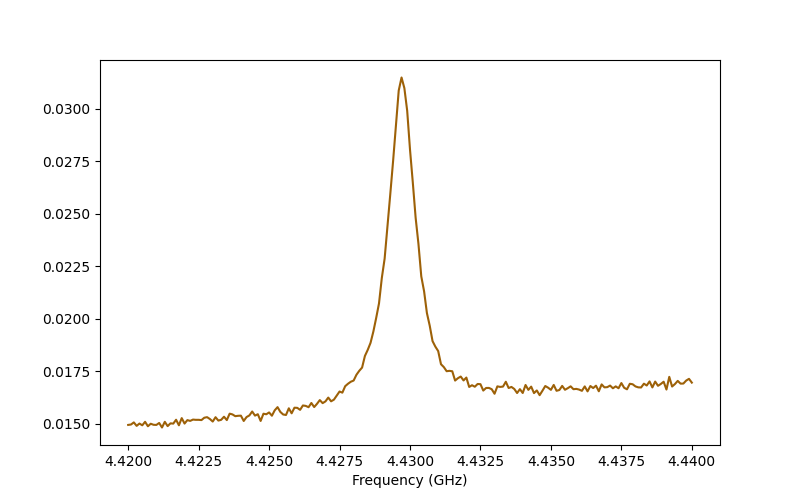

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot( freq_band, psd_band, color = color_a)
ax.set_xlabel('Frequency (GHz)')